---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.14 (Cross Validation Techniques)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

https://scikit-learn.org/stable/modules/cross_validation.html

- Recap of Evaluating a Machine Learning Model
    - No Splitting of data
    - Train-Test-Split Method (Hold-out Method)
- KFold Cross Validation
- StratifiedKFold Cross Validation
- TimeSeriesSplit Cross Validation

# 1. Recap of Evaluating a Machine Learning Model

## a. A Bad Approach
<h3 align="center"><div class="alert alert-success" style="margin: 20px">A terrible approach is to use all of the available data to train the model and then test the model using the same data</h3>

<img align="center" width="800" src="images/cv1.png"  >

## b. Train-Test-Split Method
- Holdout cross validation method involves removing a certain portion of data and using it as test data.
- The machine learning model is trained on the training data and then asked to predict the output on the test data

<img align="center" width="800" src="images/cv2.png"  >

### Basic Example

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
X = np.arange(1,101)
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=True)
print("Available Data:\n", X)
print("\nTraining Data:\n",X_train)
print("Test Data: \n", X_test)

Available Data:
 [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]

Training Data:
 [ 70  63  29  37  68   3  24  34  42   1  64  96  54  21  23  16  15  93
  73  76  49  81   4  50  59  48  91  19  32  25  94  39  40  35  12  31
  61  98  60  95  57  86  97  74  69  33  85   5  41  20  72  56  30  18
  36  26  82  75   2  66  53  92  83  52  27  62  51 100  22  79  28  58
  43  45  71  88  77   7   6  14]
Test Data: 
 [99  9 17 87 11 38 90 10 13 80 67 55 84 46  8 47 65 89 78 44]


### Example (Advertising Dataset)

<img align="center" width="1200" src="images/cv3.png"  >

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']
# Do a train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)
# Instentiate a model and fit it to training data
lr = LinearRegression().fit(X_train, y_train)
# Evaluate
r2 = r2_score(y_test, lr.predict(X_test))
r2 = lr.score(X_test, y_test)
print("R2 Score: ", r2)

R2 Score:  0.9019437827380357


**Limitations of Train-Test-Split:**
- If you execute above code again, you will get a different R2 Score. Because due to the shuffle the model get trained on different 80% of the training data and get tested on different 20% of the test data.
- Moreover, we are only evaluating our model on just 20% of the data, rather we should evaluate out model on the remaining 80% of data as well.
- Suppose you have a sample of 1000 students out of 10 million students of Pakistan. Out of 10 million students of Pakistan, the accuracy that you are getting after evaluating just 200 students might not be a true representation of the accuracy of the entire population. So even after a train-test-split, your model may overfit.
- So we want some thing more robust, let us move on to KFold Cross Validation

# 2. KFold Cross Validation
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Instead of splitting data set into a single train-test set, the data is repeatedly split into multiple train-test sets and then the model is trained and evaluated on those multiple sets</h3>


## a. Overview
**A Helper Library `mglearn`:** https://github.com/amueller/mglearn
- The book "Introduction to Machine Learning with Python" by Andreas Mueller comes handy with a helper library, which includes some utility functions that just help to draw a pretty picture quickly or to get some interesting data.

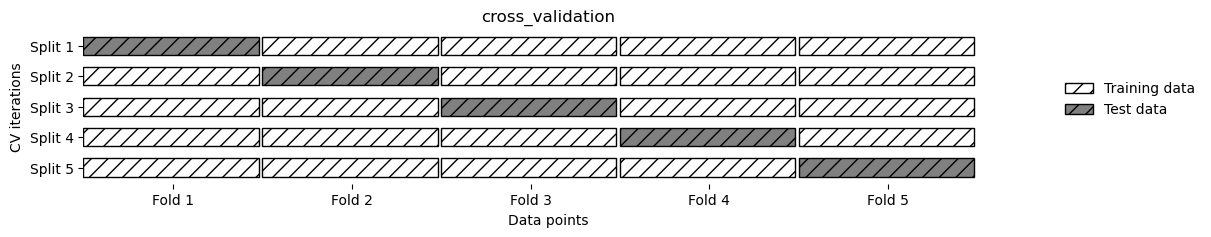

In [15]:
#import sys
#!{sys.executable} -m pip install mglearn graphviz -q
import mglearn
mglearn.plots.plot_cross_validation()

**Example: KFold Cross-Validator**
- Split dataset into k consecutive folds (without shuffling by default).
- Each fold is then used once as a validation while the k - 1 remaining folds form the training set.

In [24]:
from sklearn.model_selection import KFold
X=[0,1,2,3,4,5,6,7,8,9]

kf = KFold(n_splits=5, shuffle=True)  #change value of n_splits (2-10)

# split() method returns a generator object containing indices to split data into training and test set
for train_indices, test_indices in kf.split(X):
    print(train_indices, test_indices)

[0 1 3 4 6 7 8 9] [2 5]
[0 1 2 4 5 6 7 9] [3 8]
[0 1 2 3 4 5 8 9] [6 7]
[2 3 4 5 6 7 8 9] [0 1]
[0 1 2 3 5 6 7 8] [4 9]


> The minimum value of k in above code can be 2, and maximum value of k in above code can be 10 (Leave-One-Out)

## b. KFold on Advertising Dataset
<img align="center" width="800" src="images/cv4a.png"  >

- **Typical Steps of KFold Cross Validation:**
    - The number of folds is defined, by default this is 5
    - The dataset is split up according to these folds, where each fold has a unique set of testing data
    - A model is trained and tested for each fold
    - Each fold returns a metric/s for it's test data
    - The mean of these metrics can then be calculated to provide a single metric for the process

**Example:** Do a Five Fold Split using `KFold` on Advertising Dataset

In [25]:
df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']
kf = KFold(n_splits=5, shuffle=False)
i=1
for train_indices, test_indices in kf.split(X, y):
    print("\nSplit {}".format(i))
    print("Test Indices: ", test_indices)
    print("Training Indices: ", train_indices)
    i=i+1


Split 1
Test Indices:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Training Indices:  [ 40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57
  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75
  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93
  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111
 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129
 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147
 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165
 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183
 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Split 2
Test Indices:  [40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63
 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79]
Training Indices:  [  0   1   2   3  

### Calculate R2 Score for Linear Regression Model on all these five splits (Mannually)

In [26]:
# A user defined function, which is passed model intance along with training and testing data
# The model is trained on the training data and the function return the R2 score
def get_score(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

In [27]:
from sklearn.linear_model import LinearRegression
df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']
kf = KFold(n_splits=5, shuffle=False)

scores_list=[]
for train_indices, test_indices in kf.split(X, y):
    X_train,X_test,y_train,y_test = X.loc[train_indices], X.loc[test_indices], y[train_indices], y[test_indices]
    scores_list.append(get_score(LinearRegression(), X_train, X_test, y_train, y_test))
scores_list
print("R2 Scores: ", scores_list)
print("Mean R2 Score: ", np.mean(scores_list))

R2 Scores:  [0.8786519804831341, 0.9176321165614463, 0.9293303235799653, 0.8144390391722337, 0.8954782879224386]
Mean R2 Score:  0.8871063495438435


### Calculate R2 Score for Linear Regression Model on all the five splits (`cross_val_score`)

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

- The `cross_val_score()` method is used to evaluate a model by cross validation.

**`cross_val_score(estimator, X, y=None, cv=None, scoring=None)`**

- Where 
    - `estimator` is the instance of machine learning model
    - `X` is an array of shape (n_samples, n_features) on which the model is to be trained
    - `y` is an array of shape (n_samples,), which is the target variable
    - `cv` can be an integer value specifying the number of folds for KFold. Default is 5-fold cross validation. You can also mention the cross-validation generator that determines the cross-validation splitting strategy
    - `scoring` default value is None, in which case it uses the model's default scoring metric. But this can be overridden in the scoring parameter by passing a single string. You can pass a string specifying the metric of your choice like 'r2', 'max_error', 'neg_root_mean_squared_error',... 

- The return value is an array of scores of the estimator for each run of the cross validation



> For Details of `scoring` parameters visit: https://scikit-learn.org/stable/modules/model_evaluation.html

In [50]:
from sklearn.model_selection import cross_val_score
df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']

kf = KFold(n_splits=5, shuffle=True)
scores_array = cross_val_score(LinearRegression(), X, y, cv=kf)

#scores_array = cross_val_score(LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error')

print("R2 Scores: ", scores_array)
print("Mean R2 Score: ", np.mean(scores_array))

R2 Scores:  [-1.77102792 -1.55745554 -1.25905722 -2.32941088 -1.67067208]
Mean R2 Score:  -1.7175247278732084


### Calculate R2 Score for Linear Regression Model on all the five splits (`cross_validate`)


https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html

- The `cross_validate()` method differs from `cross_val_score()` in two ways: 
    - It allows specifying multiple scoring metrics for evaluation by passing a list of SCORERS to `scoring` argument. 
    - It returns a dict containing fit-times, score-times (and optionally training scores as well as fitted estimators) in addition to the test score.

**`cross_val_score(estimator, X, y=None, cv=None, scoring=None, return_train_score=True, return_estimator=True)`**

- Where 
    - `estimator` is the instance of machine learning model
    - `X` is an array of shape (n_samples, n_features) on which the model is to be trained
    - `y` is an array of shape (n_samples,), which is the target variable
    - `cv` can be an integer value specifying the number of folds for KFold. Default is 5-fold cross validation. You can also mention the cross-validation generator that determines the cross-validation splitting strategy
    - `scoring` default value is None, in which case it uses the model's default scoring metric. But this can be overridden in the scoring parameter by specifying a single string or list of strings of your choice like 'r2', 'max_error', 'neg_root_mean_squared_error',... 
    - `return_train_score=False`, can set it to `True` to include the train scores as well
    - `return_estimator=False`, can set it to `True` to return the estimator fitted on each split

- The return value is a dictionary of arrays containing the score/time arrays for each scorer. The possible keys of the dictionary are test_score, train_score, fit_time, score_time, estimator


> For Details of `scoring` parameters visit: https://scikit-learn.org/stable/modules/model_evaluation.html

In [52]:
from sklearn.model_selection import cross_validate
df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']

kf = KFold(n_splits=5, shuffle=False)
result_dict = cross_validate(LinearRegression(), X, y, cv=kf)
result_dict = cross_validate(LinearRegression(), X, y, cv=kf, return_train_score=True, return_estimator=True)

print(result_dict)

{'fit_time': array([0.00178003, 0.00133705, 0.00214005, 0.00190282, 0.00225902]), 'score_time': array([0.00082994, 0.0007937 , 0.00084996, 0.00080299, 0.00079203]), 'estimator': [LinearRegression(), LinearRegression(), LinearRegression(), LinearRegression(), LinearRegression()], 'test_score': array([0.87865198, 0.91763212, 0.92933032, 0.81443904, 0.89547829]), 'train_score': array([0.90101302, 0.89039598, 0.88969316, 0.91458801, 0.89615232])}


In [53]:
pd.DataFrame(result_dict)

,fit_time,score_time,estimator,test_score,train_score
0,0.001780,0.000830,LinearRegression(),0.878652,0.901013
1,0.001337,0.000794,LinearRegression(),0.917632,0.890396
2,0.002140,0.000850,LinearRegression(),0.929330,0.889693
3,0.001903,0.000803,LinearRegression(),0.814439,0.914588
4,0.002259,0.000792,LinearRegression(),0.895478,0.896152


**The `scoring` argument of `cross_validate()` method:**
- By default `cross_val_score()` and `cross_validate()` methods uses the chosen model’s default scoring metric, but this can be overridden by specifying the scoring metric in the `scoring` parameter. For `cross_Val_score()` this can be a single scoring metric, while for `cross_validate()` you can pass either a single metric or multiple as a list to the `scoring` argument.
- For Details of `scoring` parameters visit: https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
from sklearn.model_selection import cross_validate
df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']
lr = LinearRegression()

kf = KFold(n_splits=5, shuffle=False)
result_dict = cross_validate(lr, X, y, cv=kf, scoring=['r2', 'neg_mean_absolute_error'])
pd.DataFrame(result_dict)

## c. Extension to K-Fold Cross Validation
<img align="center" width="900" src="images/cv6a.png"  >

# 3. StratifiedKFold Cross Validation
## a. Overview
- The standard K-Fold Cross Validation works perfectly fine for all regression tasks, however, for classification tasks it is better to use StratifiedKFold Cross Validation. 
- For classification tasks, standard K-Fold Cross Validation may not work as expected for an imbalanced dataset or for a dataset having sorted class labels. 
- So when we have an imbalanced data set, we need a slight change to the K-Fold cross validation technique, such that each fold contains approximately the same strata of samples of each output class as the complete. 
- This variation of using a stratum in K-Fold Cross Validation is known as StratifiedKFold Cross Validation.

## b. Load Dataset
- The use of multiple measurements in Taxonomic Problems (R.A. Fisher): https://www.comp.tmu.ac.jp/morbier/R/Fisher-1936-Ann._Eugen.pdf
- Download Dataset: https://archive.ics.uci.edu/ml/datasets/Iris


<img align="center" width="600" src="images/iris.png"  > 
<img align="center" width="200" src="images/petal-sepal.png"  > 

In [54]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
X = df.drop('target', axis=1)
y = df['target']
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
np.array(y)

<img align="center" width="900" src="images/cv7a.png"  >

## c. Example 1: (iris Dataset having sorted labels)

In [55]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
X = df.drop('target', axis=1)
y = df['target']

**Use `Kold` on iris Dataset (Mannually)**

In [69]:
def get_score(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)


kf = KFold(n_splits=3, shuffle=False) # set shuffle to True and see the results by repeatedly executing this code
scores_list=[]
for train_indices, test_indices in kf.split(X, y):
    X_train,X_test,y_train,y_test = X.loc[train_indices], X.loc[test_indices], y[train_indices], y[test_indices]
    scores_list.append(get_score(LogisticRegression(solver='liblinear'), X_train, X_test, y_train, y_test))

print("R2 Scores: ", scores_list)

R2 Scores:  [0.0, 0.0, 0.0]


**Use `Kold` on iris Dataset (`cross_val_score`)**

In [ ]:
kf = KFold(n_splits=3, shuffle=False) # set shuffle to True and see the results
scores_array = cross_val_score(LogisticRegression(solver='liblinear'), X, y, cv=kf)
print("R2 Scores: ", scores_array)

In [ ]:
# For regression estimator, if cv argument is set to an integer value the cross_val_score() method use
# StratifiedKFold by default with shuffle argument set to True
scores_array = cross_val_score(LogisticRegression(solver='liblinear'), X, y, cv=3)
print("R2 Scores: ", scores_array)

**Use `StratifiedKFold` on iris Dataset (Mannually)**

In [70]:
skf = StratifiedKFold(n_splits=3, shuffle=False)

scores_list=[]
for train_indices, test_indices in skf.split(X, y):
    X_train,X_test,y_train,y_test = X.loc[train_indices], X.loc[test_indices], y[train_indices], y[test_indices]
    scores_list.append(get_score(LogisticRegression(solver='liblinear'), X_train, X_test, y_train, y_test))

print("R2 Scores: ", scores_list)

R2 Scores:  [0.96, 0.96, 0.94]


**Use `StratifiedKFold` on iris Dataset (`cross_val_score`)**

In [ ]:
skf = StratifiedKFold(n_splits=3, shuffle=False)
scores_array = cross_val_score(LogisticRegression(solver='liblinear'), X, y, cv=skf)

print("R2 Scores: ", scores_array)

In [ ]:
# For classification estimator, if cv argument is set to an integer value the cross_val_score() method use
# StratifiedKFold by default with shuffle argument set to True
scores_array = cross_val_score(LogisticRegression(solver='liblinear'), X, y, cv=3)
print("R2 Scores: ", scores_array)

## d. Example 2: (Synthetic Imbalanced Dataset)
<img align="center" width="500" src="images/cv8.png"  >

**Generate an Imbalanced Synthetic Dataset:**

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,     #number of observations
                           n_features=4,       #number of input features
                           n_classes=2,        #binary classification
                           weights=[0.95, 0.05]#95% datapoints belong to one class and 5% belong to other
                          )

In [ ]:
X

In [ ]:
y[:100]

In [ ]:
len(y[y==0])

In [ ]:
len(y[y==1])

**Split the Dataset using `KFold`:**

In [ ]:
kf = KFold(n_splits=8, shuffle=True) #perform 8 splits 
for train_indices, test_indices in kf.split(X,y):
    X_train, X_test, y_train, y_test = X[train_indices], X[test_indices], y[train_indices], y[test_indices]
    train_0, train_1 = len(y_train[y_train==0]), len(y_train[y_train==1])
    test_0, test_1 = len(y_test[y_test==0]), len(y_test[y_test==1])
    print('Train: Class0=%d, Class1=%d,        Test: Class0=%d, Class1=%d' % (train_0, train_1, test_0, test_1))

> Using KFold the model accuracy will not be the proper reflection of how well the minority class is being predicted because we have different number of minority class observations in each split of the trining and test data sets.

**Split the Dataset using `StratifiedKFold`:**

In [ ]:
skf = StratifiedKFold(n_splits=8, shuffle=True)
for train_indices, test_indices in skf.split(X,y):
    X_train, X_test, y_train, y_test = X[train_indices], X[test_indices], y[train_indices], y[test_indices]
    train_0, train_1 = len(y_train[y_train==0]), len(y_train[y_train==1])
    test_0, test_1 = len(y_test[y_test==0]), len(y_test[y_test==1])
    print('Train: Class0=%d, Class1=%d,        Test: Class0=%d, Class1=%d' % (train_0, train_1, test_0, test_1))

> Using StratifiedKFold the proportion between the classes are almost same in each fold as they are in the entire dataset. This ensures that one particular class is not over-present in the train or the test set

# 4. TimeSeriesSplit (Rolling Cross Validation)
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Peaking in the future is not allowed</h3>

- Be watchfull when splitting a TimeSeries data. The techniques discussed above may not work in case of TimeSeries data. 
- The best technique for splitting TimeSeries data is Rolling Cross Validation, which in Scikit-Learn is implemented in the `TimeSeriesSplit`
- Consider we have a TimeSeries dataset of say of 100 years.
- The left image use KFold to cross-validate timeseries data. Note that there is a chance that we train our model on future data and test on past data, thus breaking the golden rule in timeseries, i.e., "Peaking in the future is not allowed".
- The right image describe the use of `TimeSeriesSplit`, where we are creating the folds using forward chaining fashion by keeping the order intact. 

<img align="center" width="1000" src="images/cv9.ppm"  >

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
X = np.array([[9,3,4], [6,1,7], [5,2,6], [0,2,1], [5,1,7], [3,9,4], [7,3,2],[9,8,1],[4,2,7], [6,0,9]])

tss = TimeSeriesSplit(n_splits=3)
i=1
for train_indices, test_indices in tss.split(X):
    print("Split{} : {}  {}".format(i, train_indices, test_indices))
    i=i+1

In [ ]:
tss = TimeSeriesSplit(n_splits=4)
i=1
for train_indices, test_indices in tss.split(X):
    print("Split{} : {}  {}".format(i, train_indices, test_indices))
    i=i+1

# Summary of Scikit-Learn's Cross Validation Iterators
- `KFold` divides all the samples in groups of samples, called folds (if , this is equivalent to the Leave One Out strategy), of equal sizes (if possible). The prediction function is learned using folds, and the fold left out is used for test.
- `RepeatedKFold` repeats K-Fold n times. It can be used when one requires to run KFold n times, producing different splits in each repetition.
- `LeaveOneOut (LOO)` is a simple cross-validation. Each learning set is created by taking all the samples except one, the test set being the sample left out. Thus, for samples, we have different training sets and different tests set. LOO is more computationally expensive than KFold cross validation.
- `LeavePOut` is very similar to LeaveOneOut as it creates all the possible training/test sets by removing samples from the complete set. Unlike LeaveOneOut and KFold, the test sets will overlap for $p>1$.
- `ShuffleSplit` iterator will generate a user defined number of independent train / test dataset splits. Samples are first shuffled and then split into a pair of train and test sets.
- `StratifiedKFold` is a variation of k-fold which returns stratified folds: each set contains approximately the same percentage of samples of each target class as the complete set.
- `StratifiedShuffleSplit` is a variation of ShuffleSplit, which returns stratified splits, i.e which creates splits by preserving the same percentage for each target class as in the complete set.
- `GroupKFold` is a variation of k-fold which ensures that the same group is not represented in both testing and training sets. For example if the data is obtained from different subjects with several samples per-subject and if the model is flexible enough to learn from highly person specific features it could fail to generalize to new subjects. GroupKFold makes it possible to detect this kind of overfitting situations.
- `StratifiedGroupKFold` is a cross-validation scheme that combines both StratifiedKFold and GroupKFold. The idea is to try to preserve the distribution of classes in each split while keeping each group within a single split. That might be useful when you have an unbalanced dataset so that using just GroupKFold might produce skewed splits.
- `TimeSeriesSplit` is a variation of k-fold which returns first folds as train set and the $(K+1)^{th}$ fold as test set. Note that unlike standard cross-validation methods, successive training sets are supersets of those that come before them. Also, it adds all surplus data to the first training partition, which is always used to train the model.